## Inline Display of All Boreholes
This cell displays all plots directly in the notebook or saves them based on configuration.

In [6]:
# ==========================================
# BOUNDARY PLOTTING CONFIGURATION
# ==========================================
PLOT_BOUNDARIES = {
    'redox_primary': True,
    'redox_secondary': True,
    'fri_color_with_litho': True,
    'fri_color_without_litho': True,
    'geus_fri': True
}


In [7]:
# --- CONFIGURATION FOR MOVABLE PARTS ---
CONFIG = {
    'BIN_SIZE_M': 0.2,        # Discretization interval (default 1.0m per Kim et al. 2025, but for shallow boreholes with high hetereogeneity like LOOP & DEMO--> 0.2)
    'REDOX_THRESHOLD': 0.1,      # P_ox threshold for boundary (default 0.1 per Kim et al. 2025)
    'PERSISTENCE_BINS': 5,      # Number of consecutive bins required below threshold (e.g., 1 for no persistence, 2 for 1m persistence if BIN_SIZE_M=1.0)
    'DIRECTION': 'top-down',     # 'top-down' (first reduced) or 'bottom-up' (deepest oxic)
    #the following param is not needed since its turn off/on is on the above cell
    #'APPLY_LITHOLOGY_FACTOR': False #Set to False to completely ignore the 0.2 fine-grained penalty and other litho factors,
    'DEPTH_DEPENDENT_MODEL': 'linear' # 'linear' (correct per paper) or 'exponential' (original implementation)
}
# ==========================================
# ANIMATION CONFIGURATION
# ==========================================
ANIMATION_CONFIG = {
    # Speed parameter (frames per unit length). Higher = slower.
    'TOTAL_FRAMES': 300, 
    
    # Which track dictates the constant animation speed. 
    # 'Oxygen' uses the GW_DO curve.
    'MASTER_SPEED_TRACK': 'Oxygen', 
    
    # Per-borehole animation configuration.
     'BOREHOLE_OPTIONS': {
        'DEMO_D6': {'animate': True, 'interval': [4.7, 10], 'exclude_logs': []},
        'DEMO_D7': {'animate': True, 'interval': [4.5, 12], 'exclude_logs': []},
    }
}


In [8]:
import math
import re

# Table 4 params defined as (z_01, z_0)
table4_params = {
    'Grayish brown': (50.8, 76.6),
    # 'Gray': (40.1, 55.6), # REMOVED: Gray is strictly < 0.1 for Quaternary
    'Light brownish gray': (41.8, 59.9),
    'Pale brown': (39.2, 46.2), # Mapped from Light grayish brown
    'Light yellowish brown': (46.3, 51.6),
    'Dark grayish brown': (34.1, 55.9)
}

def calculate_base_pox(z, color_en, raw_pox, logic):
    logic = str(logic).strip()
    if logic == 'P_ox=1':
        return 1.0
    if logic == 'P_ox=0':
        return 0.0
    if logic == 'P_ox=0.35':
        return 0.35
    
    # X down to Y; then 0
    match = re.search(r'([0-9.]+) down to ([0-9]+)m', logic)
    if match:
        x_val = float(match.group(1))
        y_depth = float(match.group(2))
        return x_val if z <= y_depth else 0.0
        
    # Table 4 logic or Depth dependent for coarse
    if 'Table 4' in logic or 'Depth dependent' in logic:
        # Map exact string to Table 4 key
        key = str(color_en).strip()
        if key == 'Dark grayish brown' and raw_pox < 0.1: key = 'Dark grayish brown'
        elif key == 'Dark grayish brown': key = 'Grayish brown' # Gråbrun mapped to dark grayish brown but raw is 0.11
        
        if key not in table4_params:
            if 'Gray' in key: key = 'Gray'
            elif 'brownish gray' in key: key = 'Light brownish gray'
            elif 'grayish brown' in key: key = 'Grayish brown'
            else: return float(raw_pox) if pd.notna(raw_pox) else 0.0
            
        z_01, z_0 = table4_params.get(key, (0, 0))
        if z_01 == 0: return 0.0
        if z >= z_0: return 0.0
        
        A = float(raw_pox) if pd.notna(raw_pox) else 0.0
        
        if CONFIG.get('DEPTH_DEPENDENT_MODEL', 'linear') == 'linear':
            # Pure linear interpolation based strictly on Table 4 parameters: (z_01, 0.1) and (z_0, 0.0)
            slope = -0.1 / (z_0 - z_01)
            p = 0.1 + slope * (z - z_01)
            return max(0.0, min(1.0, p))
        else:
            # Original exponential implementation using Raw Oxic Fraction
            if A > 0.1:
                # Reconstruct the exponential decay k coefficient
                k = -math.log(0.1 / A) / z_01
                p = A * math.exp(-k * z)
                
                # Since exponential approaches 0 asymptotically, apply a linear taper 
                # from z_01 down to z_0 to strictly respect the paper's z_0 limit
                if z > z_01:
                    slope = -0.1 / (z_0 - z_01)
                    p = 0.1 + slope * (z - z_01)
            else:
                # If Raw Oxic Fraction is already <= 0.1 at surface (e.g. Dark grayish brown)
                # Do not project the slope backwards for shallow depths, which incorrectly increases p
                if z > z_01:
                    slope = -A / (z_0 - z_01)
                    p = A + slope * (z - z_01)
                else:
                    p = A
                
            return max(0.0, min(1.0, p))
        
    return float(raw_pox) if pd.notna(raw_pox) and str(raw_pox).replace('.','').isdigit() else 0.0

def get_litho_factor(litho_en, factor_str, pox):
    # Topsoil is ignored regardless of the flag to maintain valid structure
    if pd.isna(factor_str) or 'Ignore' in str(factor_str):
        return None # Exclude
        
    # If the user turned OFF lithology factors, we return 1.0 (no penalty)
    if not CONFIG.get('APPLY_LITHOLOGY_FACTOR', True):
        return 1.0
        
    if 'unless P_ox=1' in str(factor_str):
        return 1.0 if pox == 1.0 else 0.0
    try:
        return float(factor_str)
    except:
        return 1.0

def compute_interval_pox(row, df_cmap, df_lmap):
    z = (row['Depth_From'] + row['Depth_To']) / 2.0
    color_da = str(row['Color_Description']).strip()
    litho_da = str(row['Lithology']).strip()
    
    cmap_row = df_cmap[df_cmap['Danish Color'].str.lower() == color_da.lower()]
    lmap_row = df_lmap[df_lmap['Lithology'].str.lower() == litho_da.lower()]
    
    if cmap_row.empty or lmap_row.empty:
        return np.nan
        
    color_en = cmap_row.iloc[0]['English Equivalent']
    raw_pox = cmap_row.iloc[0]['Raw Oxic Fraction']
    try:
        raw_pox = float(raw_pox)
    except:
        raw_pox = 0.0
    logic = cmap_row.iloc[0]['Pox Definition / Logic']
    
    litho_factor_str = lmap_row.iloc[0]['Factor']
    litho_en = lmap_row.iloc[0]['Lithology_EN']
    
    base_pox = calculate_base_pox(z, color_en, raw_pox, logic)
    
    # If depth dependent for coarse but not coarse
    if 'Depth dependent for coarse' in str(logic) and 'coarse' not in str(lmap_row.iloc[0]['Feature_factor']):
        if CONFIG.get('APPLY_LITHOLOGY_FACTOR', True):
            base_pox = 0.0
        
    factor = get_litho_factor(litho_en, litho_factor_str, base_pox)
    if factor is None: 
        return np.nan
        
    return base_pox * factor



In [9]:
def calculate_fri_for_borehole(loop, id_val, df_litho, df_cmap, df_lmap):
    # Filter data
    sub = df_litho[(df_litho["LOOPNr"] == loop) & (df_litho["ID"] == id_val)].copy()
    if sub.empty: return None
    
    sub["P_ox"] = sub.apply(lambda r: compute_interval_pox(r, df_cmap, df_lmap), axis=1)
    sub = sub.dropna(subset=["P_ox"])
    
    if sub.empty: return None
    
    # Create bins
    max_depth = int(np.ceil(sub["Depth_To"].max()))
    if max_depth <= 0: return None
    bins = np.round(np.arange(0, max_depth + 1, CONFIG["BIN_SIZE_M"]), 3)
    if len(bins) < 2: return None
    bin_centers = bins[:-1] + CONFIG["BIN_SIZE_M"] / 2.0
    binned_pox = np.zeros(len(bins) - 1)
    
    for i in range(len(bins)-1):
        b_start, b_end = bins[i], bins[i+1]
        weighted_sum = 0
        total_length = 0
        
        for _, row in sub.iterrows():
            overlap_start = max(b_start, row["Depth_From"])
            overlap_end = min(b_end, row["Depth_To"])
            if overlap_start < overlap_end:
                length = overlap_end - overlap_start
                weighted_sum += length * row["P_ox"]
                total_length += length
        
        if total_length > 0:
            binned_pox[i] = weighted_sum / total_length
        else:
            binned_pox[i] = np.nan
            
    # Find FRI based on CONFIG
    fri_depth = None
    if CONFIG["DIRECTION"] == "top-down":
        for i in range(len(binned_pox) - CONFIG["PERSISTENCE_BINS"] + 1):
            valid_slice = binned_pox[i:i+CONFIG["PERSISTENCE_BINS"]]
            if not np.isnan(valid_slice).any() and np.all(valid_slice <= CONFIG["REDOX_THRESHOLD"]):
                # Place interface EXACTLY at the top edge of the first reduced block
                fri_depth = bins[i]
                break
    elif CONFIG["DIRECTION"] == "bottom-up":
        # Search from bottom up, looking for a valid PERSISTENCE block of OXIC sediment
        deepest_oxic_idx = -1
        req_bins = CONFIG["PERSISTENCE_BINS"]
        
        for i in range(len(binned_pox) - req_bins, -1, -1):
            valid_slice = binned_pox[i:i+req_bins]
            if not np.isnan(valid_slice).any() and np.all(valid_slice > CONFIG["REDOX_THRESHOLD"]):
                # Found a continuous block of oxic sediment!
                deepest_oxic_idx = i + req_bins - 1
                break
                
        if deepest_oxic_idx != -1:
            # We found the deepest oxic block. Now verify there is a reduced layer below it!
            has_reduced_below = False
            for j in range(deepest_oxic_idx + 1, len(binned_pox)):
                if not np.isnan(binned_pox[j]):
                    if binned_pox[j] <= CONFIG["REDOX_THRESHOLD"]:
                        has_reduced_below = True
                    break # Only check the very next valid bin
                    
            if has_reduced_below:
                # Place interface EXACTLY at the bottom edge of the oxic block
                fri_depth = bins[deepest_oxic_idx + 1]
            else:
                # Log ends in oxic material (no reduced data below). Interface is deeper than borehole.
                fri_depth = None
        else:
            # If we never found a persistent oxic layer (the whole log is effectively reduced), 
            # the interface is at the very top (the top edge of the first valid bin)
            for i in range(len(binned_pox)):
                if not np.isnan(binned_pox[i]):
                    fri_depth = bins[i]
                    break

    return {"LOOPNr": loop, "ID": id_val, "Color_FRI_Depth": fri_depth, "Binned_Pox": binned_pox, "Bin_Centers": bin_centers}




Found 27 boreholes. Global Max Depth: 25.62m



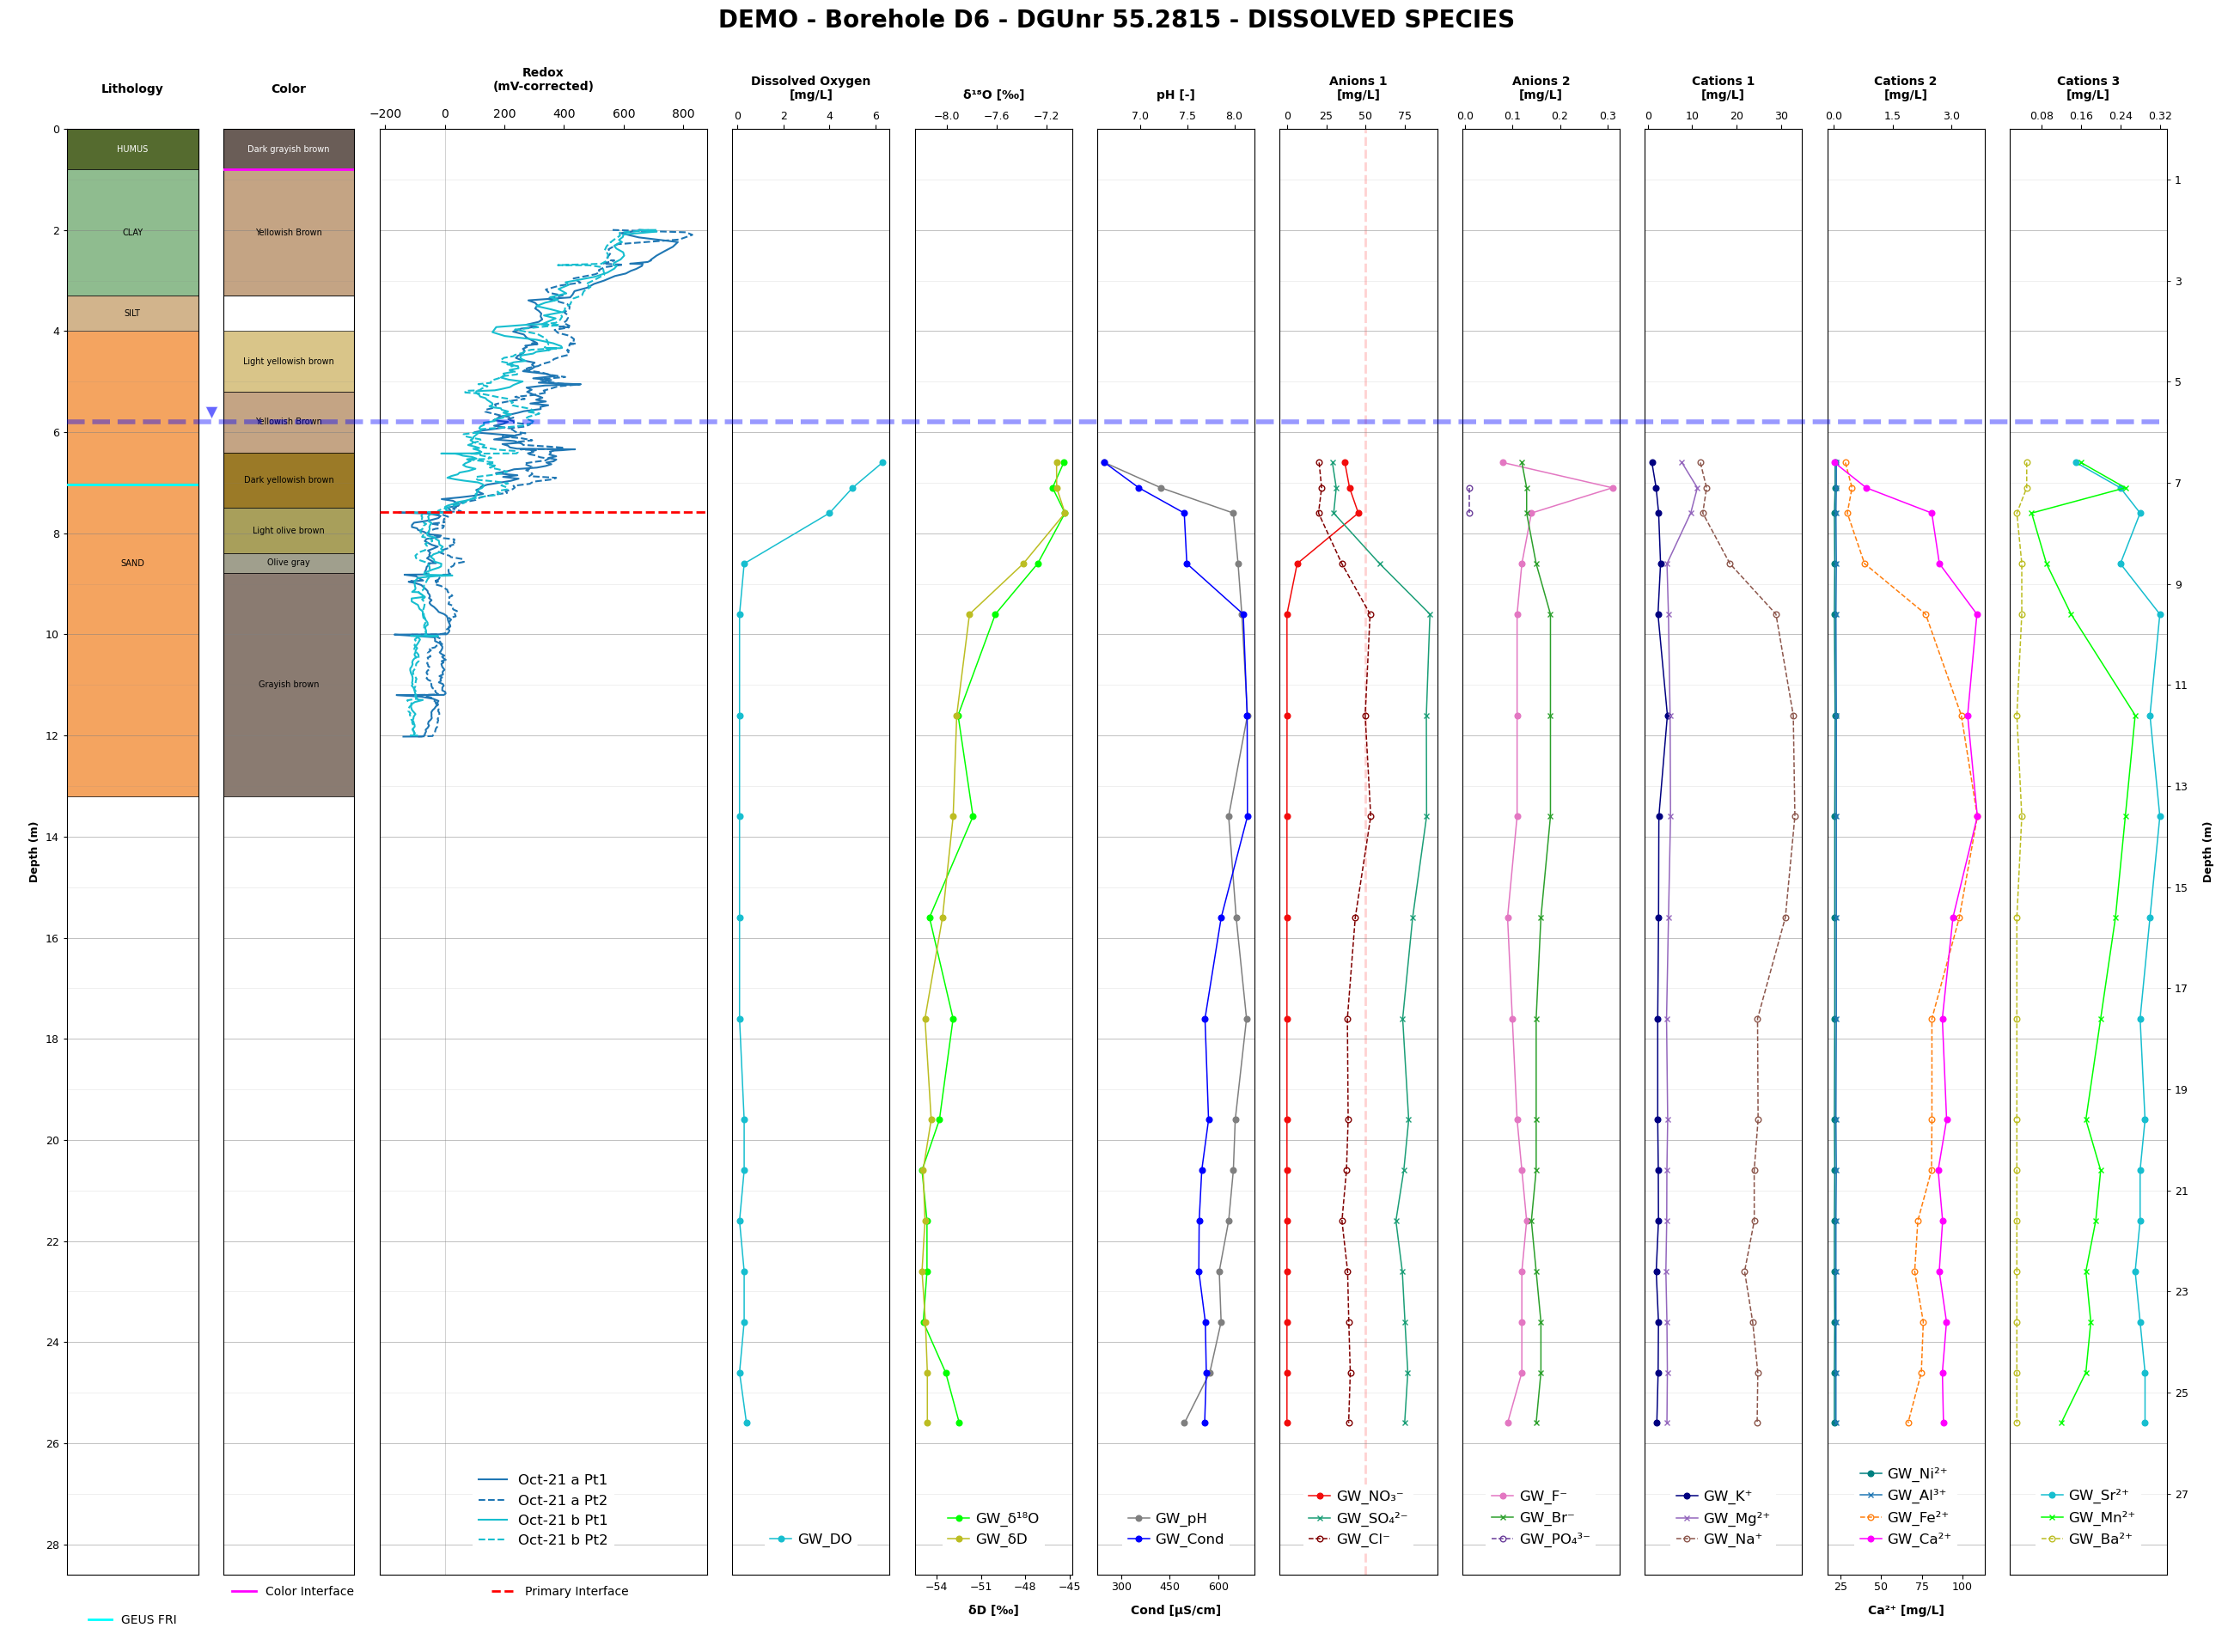


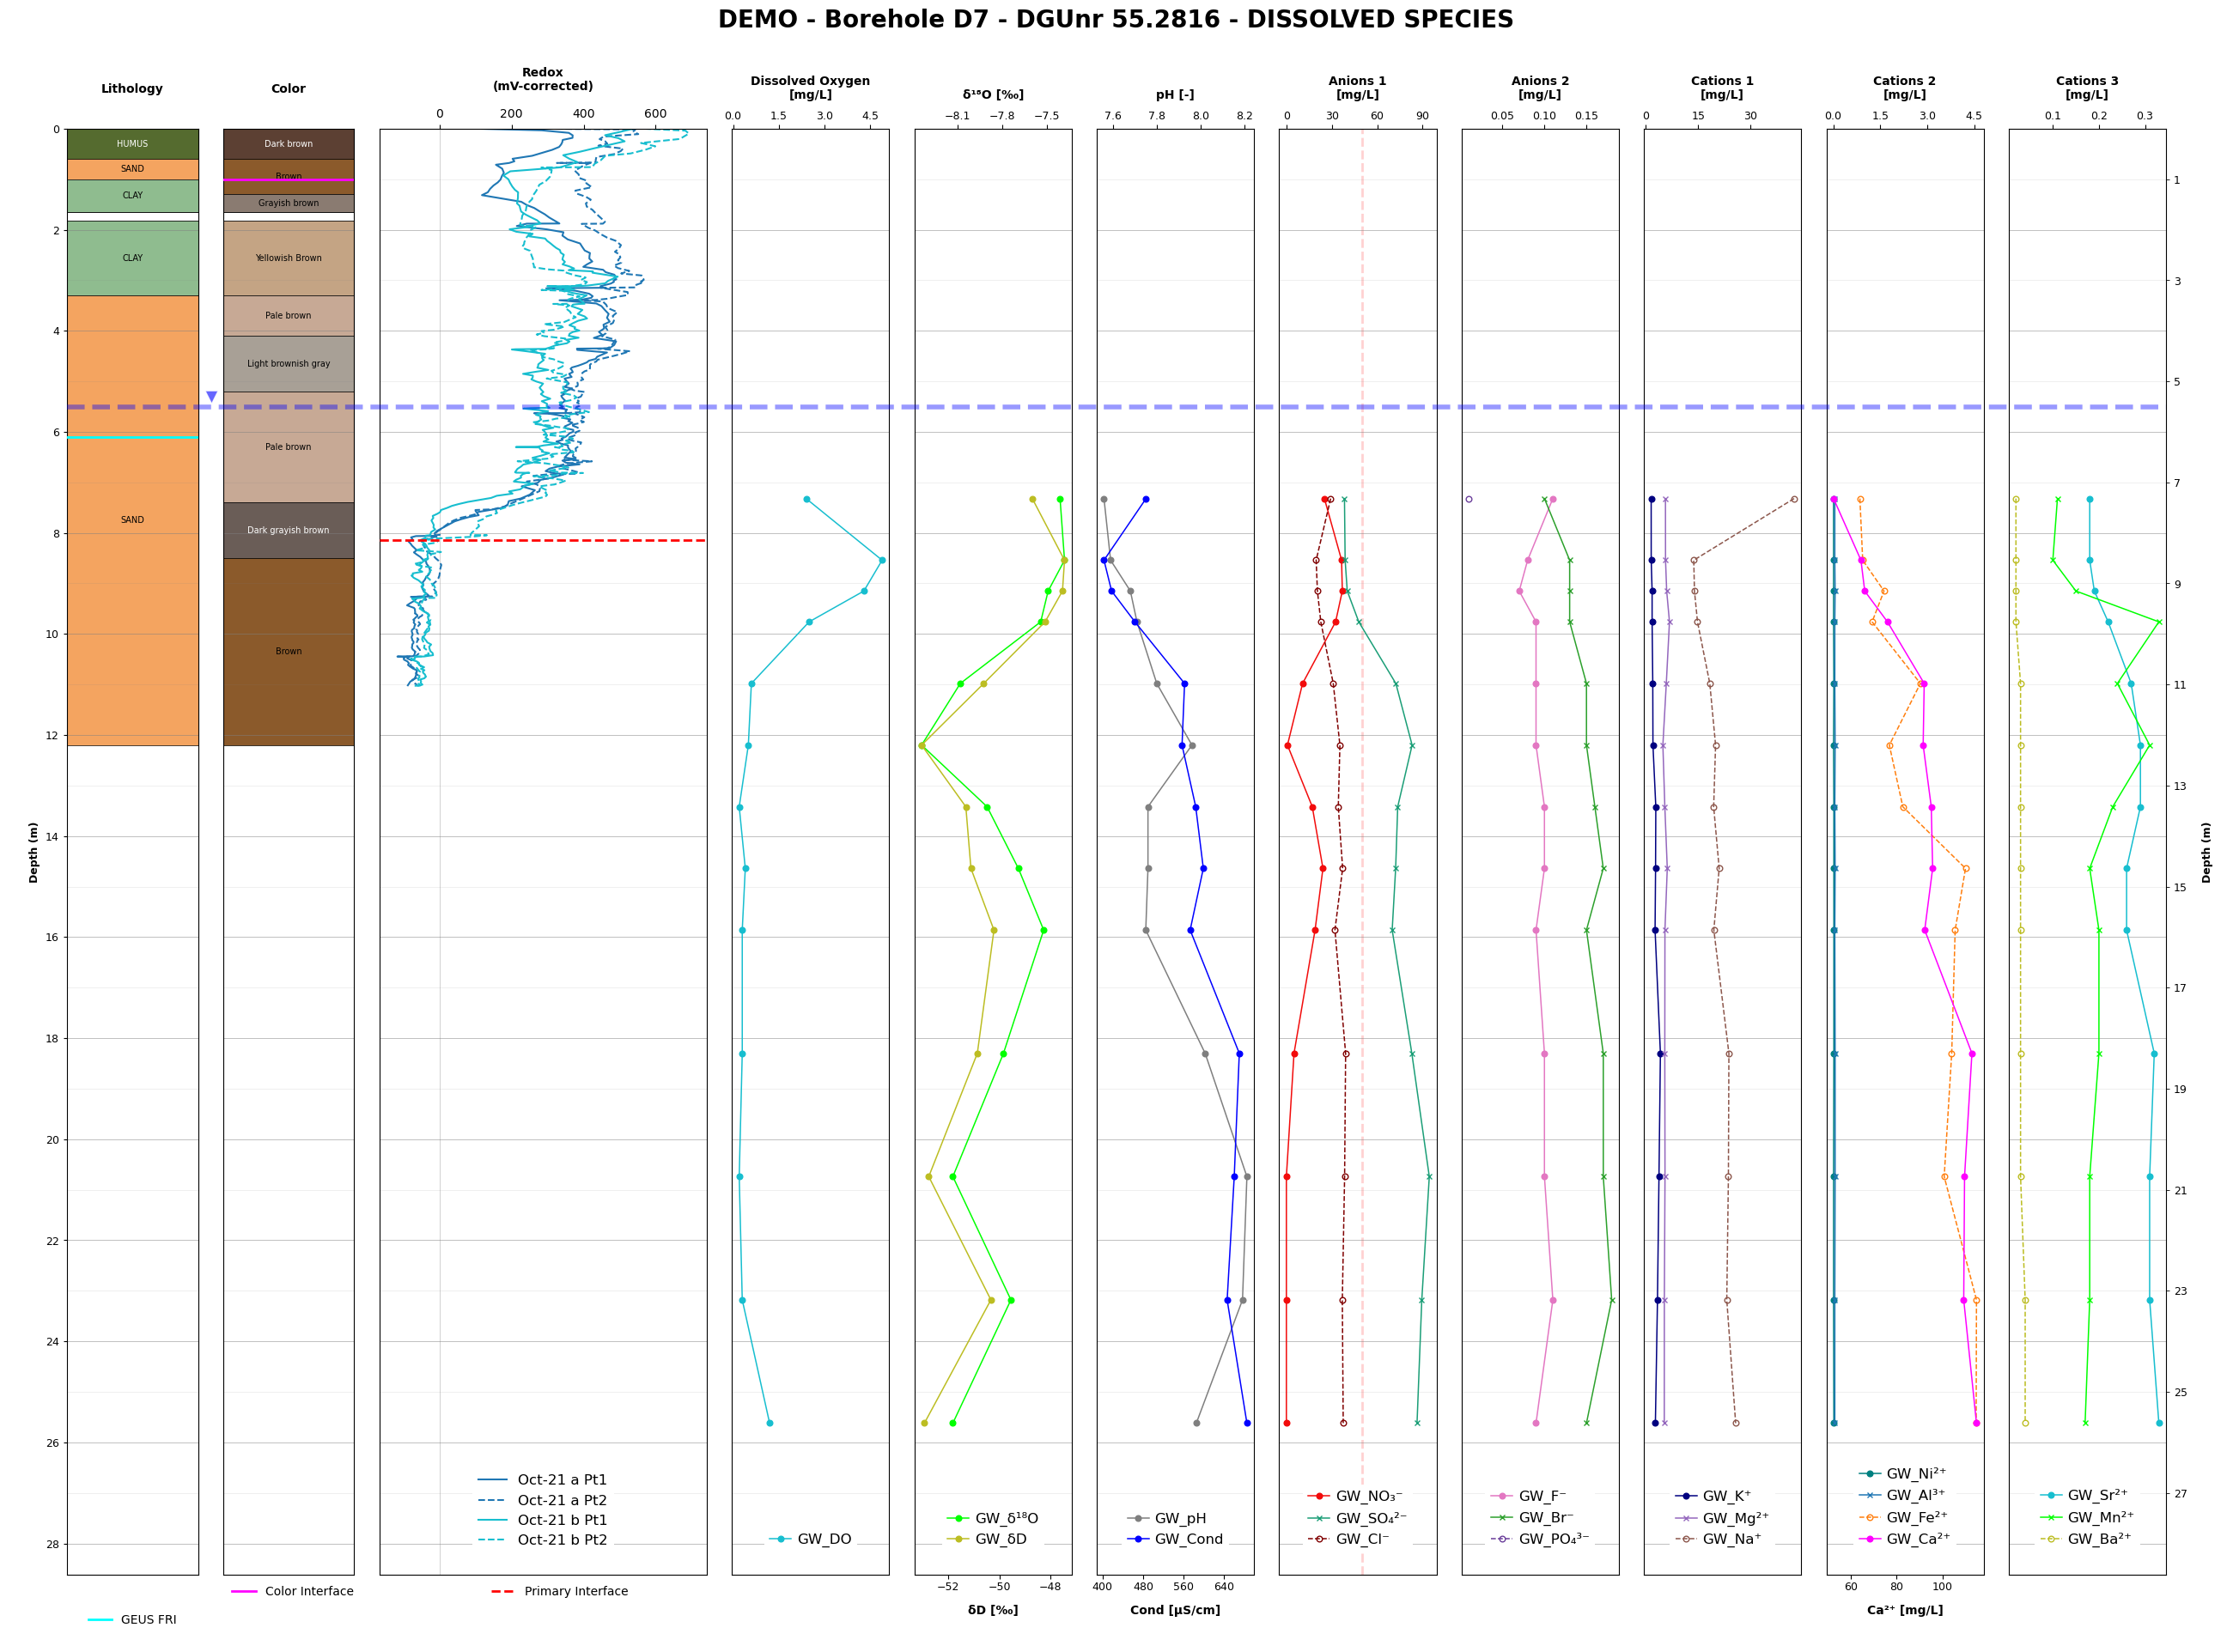

In [10]:
# --- CONFIGURATION ---
# Set to True to display plots inline in the notebook.
# Set to False to save plots to the 'output_plots_v' directory instead.
SHOW_INLINE = True
output_folder = "output_plots_v"
import os
if not SHOW_INLINE and not os.path.exists(output_folder):
    os.makedirs(output_folder)
# ---------------------
# ==========================================
# PLOTTING SCRIPT VERSION 3 (Added GWT & Redox Interfaces)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np
import os
import re
import itertools
import random
# ==========================================
# 0. TRACKS TO INCLUDE
# ==========================================
GEOCHEM_TRACKS = [
    dict(gs=3,  top=['GW_DO [mg/L]'], bot=[],
         title_top="Dissolved Oxygen\n[mg/L]", title_bot=None, is_last=False),
    dict(gs=4,  top=['GW_δ¹⁸O [‰]'], bot=['GW_δD [‰]'],
         title_top="δ¹⁸O [‰]", title_bot="δD [‰]", is_last=False),
    dict(gs=5,  top=['GW_pH [-]'], bot=['GW_Cond [µS/cm]'],
         title_top="pH [-]", title_bot="Cond [µS/cm]", is_last=False),
    dict(gs=6,  top=['GW_NO₃⁻ [mg/L]', 'GW_SO₄²⁻ [mg/L]', 'GW_Cl⁻ [mg/L]'], bot=[],
         title_top="Anions 1\n[mg/L]", title_bot=None, is_last=False),
    dict(gs=7,  top=['GW_F⁻ [mg/L]', 'GW_Br⁻ [mg/L]', 'GW_PO₄³⁻ [mg/L]'], bot=[],
         title_top="Anions 2\n[mg/L]", title_bot=None, is_last=False),
    dict(gs=8,  top=['GW_K⁺ [mg/L]', 'GW_Mg²⁺ [mg/L]', 'GW_Na⁺ [mg/L]'], bot=[],
         title_top="Cations 1\n[mg/L]", title_bot=None, is_last=False),
    dict(gs=9,  top=['GW_Ni²⁺ [mg/L]', 'GW_Al³⁺ [mg/L]', 'GW_Fe²⁺ [mg/L]'], bot=['GW_Ca²⁺ [mg/L]'],
         title_top="Cations 2\n[mg/L]", title_bot="Ca²⁺ [mg/L]", is_last=False),
    dict(gs=10, top=['GW_Sr²⁺ [mg/L]', 'GW_Mn²⁺ [mg/L]', 'GW_Ba²⁺ [mg/L]'], bot=[],
         title_top="Cations 3\n[mg/L]", title_bot=None, is_last=True),
]
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
# Relative paths (Modify if needed)
path_litho_master = os.path.join('..', 'Python_Redox_Geochemistry', 'Lithology', 'Master_Lithology.csv')
path_litho_map = os.path.join('..', 'Python_Redox_Geochemistry', 'Lithology', 'Lithology_mapping.csv')
path_color_map = os.path.join('..', 'Python_Redox_Geochemistry', 'Lithology', 'Color_mapping.csv')
path_redox = os.path.join('..', 'Python_Redox_Geochemistry', 'Redox', 'Master_Redox.csv')
path_geochem = os.path.join('..', 'Python_Redox_Geochemistry', 'Geochemistry', 'Master_Geochemistry.csv')
path_metadata = os.path.join('..', 'Python_Redox_Geochemistry', 'Borehole_Metadata.csv')
def load_and_clean(path):
    encodings = ['utf-8-sig', 'utf-8', 'latin1', 'cp1252']
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            # Clean column names
            df.columns = df.columns.str.strip().str.replace('^ï»¿', '', regex=True)
            return df
        except Exception:
            continue
    raise ValueError(f"Failed to read {path}")
# Load Data
try:
    df_litho = load_and_clean(path_litho_master)
    df_litho_map = load_and_clean(path_litho_map)
    df_color_map = load_and_clean(path_color_map)
    df_redox = load_and_clean(path_redox)
    df_geochem = load_and_clean(path_geochem)
except Exception as e:
    print(f"Error loading files: {e}")
    raise
try:
    df_metadata = pd.read_csv(path_metadata)
except:
    df_metadata = pd.DataFrame()
# ==========================================
# 2. PREPROCESSING & NORMALIZATION
# ==========================================
# Clean String Columns
for df in [df_litho, df_litho_map, df_color_map, df_redox, df_geochem]:
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip()
# Merge Lithology Mappings
df_litho = pd.merge(df_litho, df_litho_map[['Lithology', 'Lithology_simple_EN']], on='Lithology', how='left')
df_litho = pd.merge(df_litho, df_color_map[['Danish Color', 'English Equivalent']],
                    left_on='Color_Description', right_on='Danish Color', how='left')
df_litho['English Equivalent'] = df_litho['English Equivalent'].fillna(df_litho['Color_Description'])
# Clean Redox Data
df_redox['DateTime'] = pd.to_datetime(df_redox['DateTime'], errors='coerce')
if 'Redox_mV' in df_redox.columns:
    df_redox['Redox_mV_Plot'] = df_redox['Redox_mV'] + 225
else:
    df_redox['Redox_mV_Plot'] = np.nan
# --- NORMALIZE IDs FOR MATCHING ---
def normalize_id(row, source):
    loop = str(row['LOOPNr']).strip().upper()
    raw_id = str(row['ID']).strip()
    if source == 'Redox':
        # 1. Remove trailing run letters (e.g., '6a' -> '6')
        norm = re.sub(r'[a-z]$', '', raw_id, flags=re.IGNORECASE)
        # 2. Handle DEMO loop specifically: If ID is numeric (like '6'), make it 'D6'
        if loop == 'DEMO':
            if norm.isdigit():
                norm = f"D{norm}"
        # 3. Handle LOOP4 specific replacements
        if loop == 'LOOP4':
            norm = norm.replace('Geological Window-', 'GeoW-')
            norm = norm.replace('interglacial sand-', 'IS-')
            norm = norm.replace('meltwater sand-', 'MS-')
            norm = norm.replace('Til layer-', 'TL-')
        return norm
    elif source == 'Geochem':
        # If Geochem already has 'D6', 'D7', etc., we leave it 
        # so it matches the newly normalized Redox IDs.
        if loop in ['LOOP2', 'LOOP3', 'LOOP6']:
            norm = re.sub(r'^P', '', raw_id)  # Remove leading P
            return norm
        return raw_id
df_redox['Normalized_ID'] = df_redox.apply(lambda row: normalize_id(row, 'Redox'), axis=1)
df_geochem['Normalized_ID'] = df_geochem.apply(lambda row: normalize_id(row, 'Geochem'), axis=1)
path_gwt = os.path.join('..', 'Python_Redox_Geochemistry', 'Lithology', 'GWT.csv')
algo_path = '../Interface_Detection/Extracted_Advanced_Interfaces.csv'
try:
    df_gwt_raw = pd.read_csv(path_gwt, sep=',', encoding='utf-8')
    def parse_gwt_sounding(s):
        s = str(s).strip().upper()
        if 'DEMO' in s:
            match = re.search(r'\d+', s)
            return 'DEMO', f"D{match.group()}" if match else None
        elif 'LOOP' in s:
            s = s.replace('LOOP ', 'LOOP')
            match = re.search(r'(LOOP\d+)\s+BOREHOLE\s+(.*)', s)
            if match:
                loop = match.group(1)
                raw_id = match.group(2).strip()
                norm = raw_id
                if loop == 'LOOP4':
                    norm = norm.replace('GW2', 'GeoW-2').replace('MWS1', 'MS-1').replace('MWS2', 'MS-2')
                    norm = norm.replace('TIL2', 'TL-2').replace('TIL', 'TL-1')
                elif loop in ['LOOP2', 'LOOP3', 'LOOP6']:
                    norm = re.sub(r'^P', '', norm)
                return loop, norm
        return None, None
    gwt_list = []
    for _, row in df_gwt_raw.iterrows():
        loop, norm_id = parse_gwt_sounding(row['Sounding'])
        if loop and norm_id:
            try:
                val = float(row['GWT'])
                gwt_list.append({'LOOPNr': loop, 'Normalized_ID': norm_id, 'GWT': val})
            except:
                pass
    df_gwt = pd.DataFrame(gwt_list)
except Exception as e:
    print(f"Error loading GWT.csv: {e}")
    df_gwt = pd.DataFrame(columns=['LOOPNr', 'Normalized_ID', 'GWT'])
try:
    df_algo = pd.read_csv(algo_path)
    # The Extracted_Advanced_Interfaces.csv has 'ID' column. Let's normalize it.
    df_algo['Norm_ID'] = df_algo.apply(lambda row: normalize_id(row, 'Redox'), axis=1)
    df_interfaces = df_algo.groupby(['LOOPNr', 'Norm_ID'])[['Main_Drop_Z', 'Sec_Drop_Z']].mean().reset_index()
except Exception as e:
    print(f"Error loading Algo_2026_Results.csv: {e}")
    df_interfaces = pd.DataFrame(columns=['LOOPNr', 'Norm_ID', 'Auto_1', 'Auto_2'])
# Find Valid Intersections
geochem_keys = df_geochem[['LOOPNr', 'ID', 'Normalized_ID']].drop_duplicates()
valid_plots = []
# --- CALCULATE GLOBAL MAX DEPTH FOR ASPECT RATIO ---
global_max_depth_batch = 10
for _, row in geochem_keys.iterrows():
    loop = row['LOOPNr']
    norm_id = row['Normalized_ID']
    disp_id = row['ID']
    # Check if redox exists
    redox_subset = df_redox[(df_redox['LOOPNr'] == loop) & (df_redox['Normalized_ID'] == norm_id)]
    if not redox_subset.empty:
        valid_plots.append((loop, disp_id, norm_id))
        # Check depths for this borehole
        litho_subset = df_litho[(df_litho['LOOPNr'] == loop) & (df_litho['ID'] == disp_id)]
        geo_subset = df_geochem[(df_geochem['LOOPNr'] == loop) & (df_geochem['ID'] == disp_id)]
        d1 = litho_subset['Depth_To'].max() if not litho_subset.empty else 0
        d2 = redox_subset['Depth'].max() if not redox_subset.empty else 0
        d3 = geo_subset['Depth (m)'].max() if not geo_subset.empty else 0
        local_max = max(d1, d2, d3)
        if local_max > global_max_depth_batch:
            global_max_depth_batch = local_max
print(f"Found {len(valid_plots)} boreholes. Global Max Depth: {global_max_depth_batch}m")
# ==========================================
# 3. HELPER FUNCTIONS & STYLING
# ==========================================
# --- CONSTANT FONT SIZES ---
TITLE_SIZE = 10
LABEL_SIZE = 9
TICK_SIZE = 9
LEGEND_SIZE = 12
# # --- layout constants (tune once, then it's consistent for all files) ---
# TOP = 0.92        # top of the subplot block (everything below suptitle)
# BOTTOM = 0.09     # your legend room at the bottom
# LEFT = 0.03
# RIGHT = 0.99
# SUPTITLE_Y = 0.975  # suptitle position; keep a fixed gap to TOP
# ==========================================
# 3. HELPER FUNCTIONS & STYLING
# ==========================================
# ... (Keep existing constants and get_litho_color function) ...
def get_color_hex(color_name):
    if pd.isna(color_name) or str(color_name).lower() in ['nan', 'none', 'no sample']: 
        return 'none'
    # Standardize input string
    c = str(color_name).lower().strip()
    c = c.replace('grey', 'gray')
    # Comprehensive dictionary mapping
    color_dict = {
        # Yellows & Light Browns
        'pale yellow': '#F5EDB0',
        'light yellowish brown': '#D9C589',
        'yellowish brown': '#C4A484',
        'dark yellowish brown': '#9B7A27',
        'pale brown': '#C7A995',
        'light olive brown': '#A89F5B',
        # Browns
        'brown': '#8B5A2B',
        'dark grayish brown': '#6A5D57',
        'grayish brown': '#8A7B71',
        'reddish brown': '#A0522D',
        'dark brown': '#5C4033',       # Updated hex
        'mørk brun': '#5C4033',        # Maps to Dark brown
        'blackish brown': '#3D2314',
        'olive brown': '#6B6032',
        # Grays
        'light gray': '#D3D3D3',
        'light yellowish gray': '#DCD0BA',
        'light brownish gray': '#A8A096',
        'gray': '#808080',
        'olive gray': '#A09F8D',       # Updated hex
        'olivengrå': '#A09F8D',        # Maps to Olive gray
        'dark greenish gray': '#4A5D4E',
        'dark gray': '#5A5A5A',
        'blackish gray': '#363839',    # Updated hex
        'sortgrå': '#363839',          # Maps to Blackish gray
        # Blacks
        'light brownish black': '#2B2522',
        'black': '#1C1C1C'
    }
    return color_dict.get(c, '#E0E0E0') 
def get_litho_text_color(bg_hex):
    """Used for Track 1: Determines text color based on the Lithology hex code."""
    if bg_hex == 'none': return 'none'
    # Dark hex codes used in get_litho_color (e.g., Peat, Gyttja)
    dark_litho_colors = ['#556B2F', '#808000']
    return 'white' if bg_hex in dark_litho_colors else 'black'
def get_sediment_text_color(color_name):
    """Used for Track 2: Determines text color explicitly by sediment color name."""
    if pd.isna(color_name) or str(color_name).lower() in ['nan', 'none', 'no sample']: 
        return 'none'
    c = str(color_name).lower().strip()
    c = c.replace('grey', 'gray')
    white_text_colors = [
        'reddish brown', 'dark gray', 'light brownish black',
        'dark brown', 'mørk brun', 'blackish brown', 'black',
        'dark grayish brown', 'dark greenish gray', 'olive brown',
        'gray', 'blackish gray', 'sortgrå'
    ]
    return 'white' if c in white_text_colors else 'black'
def get_litho_color(litho_simple):
    if pd.isna(litho_simple) or str(litho_simple).lower() in ['nan', 'none', 'no sample']: return 'none'
    l = str(litho_simple).upper()
    if 'CLAY' in l: return '#8FBC8F'
    if 'SAND' in l: return '#F4A460'
    if 'SILT' in l: return '#D2B48C'
    if 'GRAVEL' in l: return '#A9A9A9'
    if 'PEAT' in l or 'HUMUS' in l: return '#556B2F'
    if 'GYTTJA' in l: return '#808000'
    return '#E0E0E0'
def merge_intervals(df, col_to_check):
    if df.empty: return df
    df = df.sort_values('Depth_From').reset_index(drop=True)
    merged = []
    if len(df) == 0: return pd.DataFrame()
    current = df.iloc[0].copy()
    for i in range(1, len(df)):
        row = df.iloc[i]
        if (row['Depth_From'] == current['Depth_To']) and (row[col_to_check] == current[col_to_check]):
            current['Depth_To'] = row['Depth_To']
        else:
            merged.append(current)
            current = row.copy()
    merged.append(current)
    return pd.DataFrame(merged)
# --- HIGH CONTRAST / SHUFFLED COLORS ---
def get_high_contrast_cycle():
    base_colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#000080', '#FF00FF', '#008080', '#800000', '#00FF00', '#0000FF'
    ]
    random.seed(42)
    random.shuffle(base_colors)
    return itertools.cycle(base_colors)
color_gen = get_high_contrast_cycle()
assigned_colors = {}
MANUAL_COLORS = {
    'NO₃⁻ [mg/L]': "#F20B0B",
    'PO₄⁻ [mg/L]': '#6a3d9a',
    'SO₄²⁻ [mg/L]': '#1b9e77',
    # ... add more as you wish
}
def get_param_color(param_name):
    # Strip GW_ and fix PO4 naming to map back to original colors
    base_name = param_name.replace('GW_', '').replace('PO₄³⁻', 'PO₄⁻')
    if base_name in MANUAL_COLORS:
        return MANUAL_COLORS[base_name]
    if base_name not in assigned_colors:
        assigned_colors[base_name] = next(color_gen)
    return assigned_colors[base_name]
def style_legend_white_no_outline(leg):
    if leg is None:
        return
    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("none")
    frame.set_linewidth(0.0)
    frame.set_alpha(1.0)
# --- SHIFT Redox depths for DEMO / Borehole 6 by +2 m ---
def _is_borehole_6(x):
    s = str(x).strip().upper()
    # grab the first integer found (handles "6", "06", "P6", "BH6", etc.)
    m = re.search(r'\d+', s)
    return (m is not None) and (int(m.group()) == 6)
# derived automatically (so GW_* will never be included unless you add it to a track)
PLOTTED_GEOCHEM_COLS = set()
for t in GEOCHEM_TRACKS:
    PLOTTED_GEOCHEM_COLS.update(t['top'])
    PLOTTED_GEOCHEM_COLS.update(t['bot'])
PLOTTED_GEOCHEM_COLS.discard(None)
def max_depth_geochem_plotted(sub_geo: pd.DataFrame, plotted_cols: set) -> float:
    if sub_geo.empty or 'Depth (m)' not in sub_geo.columns:
        return np.nan
    depth = pd.to_numeric(sub_geo['Depth (m)'], errors='coerce')
    cols = [c for c in plotted_cols if c in sub_geo.columns]
    if not cols:
        return np.nan
    any_plotted = pd.Series(False, index=sub_geo.index)
    for c in cols:
        any_plotted |= pd.to_numeric(sub_geo[c], errors='coerce').notna()
    m = any_plotted & depth.notna()
    return float(depth[m].max()) if m.any() else np.nan
# ==========================================
# 4. PLOTTING CORE
# ==========================================
valid_plots = [(loop, disp, norm) for loop, disp, norm in valid_plots if loop == 'DEMO' and disp in ['D6', 'D7']]
for loop_nr, display_id, normalized_id in valid_plots:
    redox_lines = []
    nitrate_lines_info = []; oxygen_lines_info = []
    sub_litho = df_litho[(df_litho['LOOPNr'] == loop_nr) & (df_litho['ID'] == display_id)].copy()
    sub_redox = df_redox[(df_redox['LOOPNr'] == loop_nr) & (df_redox['Normalized_ID'] == normalized_id)].copy()
    if str(loop_nr).strip().upper() == "DEMO" and _is_borehole_6(display_id):
        sub_redox["Depth"] = pd.to_numeric(sub_redox["Depth"], errors="coerce") + 2.0
    sub_geo = df_geochem[(df_geochem['LOOPNr'] == loop_nr) & (df_geochem['ID'] == display_id)].copy()
    dgu_nr = sub_geo['DGUnr'].iloc[0] if 'DGUnr' in sub_geo.columns else "?"
    # --- Metadata for GEUS FRI ---
    meta_row = df_metadata[(df_metadata['LOOPNr'] == loop_nr) & (df_metadata['ID'] == normalized_id)] if not df_metadata.empty else pd.DataFrame()
    # --- USE LOCAL SCALING FOR HEIGHT (PER BOREHOLE) + SPACE FOR LEGENDS ---
    d1 = pd.to_numeric(sub_litho['Depth_To'], errors='coerce').max() if ('Depth_To' in sub_litho.columns and not sub_litho.empty) else np.nan
    d2 = pd.to_numeric(sub_redox['Depth'], errors='coerce').max() if ('Depth' in sub_redox.columns and not sub_redox.empty) else np.nan
    d3 = max_depth_geochem_plotted(sub_geo, PLOTTED_GEOCHEM_COLS)
    local_max_depth = float(np.nanmax([d1, d2, d3, 0.0]))
    legend_pad_m = 3.0  # <-- tune: how many meters of blank space at bottom for legends
    plot_depth_limit = max(2.0, local_max_depth + legend_pad_m)
    # Figure height scales with local depth (same spirit as your v6 code)
    fig_height = (plot_depth_limit * 0.55) + 3.5
    fig_height = max(8.0, fig_height)
    fig = plt.figure(figsize=(26, fig_height))
    # ---- desired absolute layout (in inches) ----
    TOP_EDGE_TO_SUPTITLE_IN = 0.10     # top edge -> suptitle baseline
    TOP_EDGE_TO_AXES_IN     = 1.5     # top edge -> top of subplot block
    BOTTOM_MARGIN_IN        = 0.90     # bottom edge -> subplot block bottom
    LEFT, RIGHT             = 0.03, 0.97
    H = fig.get_figheight()  # inches
    suptitle_y = 1 - (TOP_EDGE_TO_SUPTITLE_IN / H)
    top        = 1 - (TOP_EDGE_TO_AXES_IN     / H)
    bottom     = (BOTTOM_MARGIN_IN / H)
    fig.suptitle(
        f"{loop_nr} - Borehole {display_id} - DGUnr {dgu_nr} - DISSOLVED SPECIES",
        fontsize=20, weight="bold", y=suptitle_y
    )
    gs = gridspec.GridSpec(
        1, 11,
        figure=fig,
        left=LEFT, right=RIGHT,
        bottom=bottom, top=top,
        width_ratios=[1, 1, 2.5, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2],
        wspace=0.15
    )
    even_loc = ticker.IndexLocator(base=2, offset=0)  # 0,2,4,...
    odd_loc  = ticker.IndexLocator(base=2, offset=1)  # 1,3,5,...
    def setup_ticks(ax, is_left=False, is_right=False):
        ax.set_ylim(plot_depth_limit, 0)
        # Build explicit tick positions so odds ALWAYS include 1
        y_max = int(np.ceil(plot_depth_limit))
        even_ticks = np.arange(0, y_max + 1, 2)   # 0,2,4,...
        odd_ticks  = np.arange(1, y_max + 1, 2)   # 1,3,5,...
        ax.yaxis.set_major_locator(ticker.FixedLocator(even_ticks))
        ax.yaxis.set_minor_locator(ticker.FixedLocator(odd_ticks))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
        ax.yaxis.set_minor_formatter(ticker.FormatStrFormatter('%d'))
        # Grid: even strong, odd subtle
        ax.grid(True, axis='y', which='major', linestyle='-', linewidth=0.7, alpha=0.50, color='gray')
        ax.grid(True, axis='y', which='minor', linestyle='-', linewidth=0.5, alpha=0.18, color='gray')
        # Default: NO y ticks anywhere (clean look)
        ax.tick_params(axis='y', which='major',
                    left=False, right=False, labelleft=False, labelright=False, length=0)
        ax.tick_params(axis='y', which='minor',
                    left=False, right=False, labelleft=False, labelright=False, length=0)
        # Far-left: show EVEN ticks/labels only (major)
        if is_left:
            ax.set_ylabel("Depth (m)", fontsize=LABEL_SIZE, fontweight='bold')
            ax.yaxis.set_label_position("left")
            ax.tick_params(axis='y', which='major',
                        left=True, labelleft=True, labelsize=TICK_SIZE, length=3)
            # keep odd tick marks/labels off on left (but grid still draws)
            ax.tick_params(axis='y', which='minor', left=False, labelleft=False)
        # Far-right: show ODD ticks/labels only (minor), ONLY on last track
        if is_right:
            ax.set_ylabel("Depth (m)", fontsize=LABEL_SIZE, fontweight='bold', labelpad=12)
            ax.yaxis.set_label_position("right")
            ax.tick_params(axis='y', which='minor',
                        right=True, labelright=True, labelsize=TICK_SIZE, length=3)
            # ensure even labels never appear on the right
            ax.tick_params(axis='y', which='major', right=False, labelright=False)
    # --- TRACK 1: LITHOLOGY ---
    ax_lith = plt.subplot(gs[0])
    setup_ticks(ax_lith, is_left=True)
    ax_lith.set_title("Lithology", fontsize=TITLE_SIZE, loc='center', pad=30, fontweight ='bold')
    ax_lith.set_xticks([])
    merged_lith = merge_intervals(sub_litho, 'Lithology_simple_EN')
    for _, row in merged_lith.iterrows():
        top, bottom = row['Depth_From'], row['Depth_To']
        h = bottom - top
        name = row['Lithology_simple_EN']
        # Handle "NO SAMPLE"
        is_no_sample = str(name).upper() == 'NO SAMPLE'
        if is_no_sample:
            fill_col = 'none'
            txt = "NO SAMPLE"
            txt_col = 'black'
        else:
            fill_col = get_litho_color(name)
            txt = name if fill_col != 'none' else ''
            txt_col = get_litho_text_color(fill_col)
        rect = patches.Rectangle((0, top), 1, h, linewidth=0.5, edgecolor='black', facecolor=fill_col)
        ax_lith.add_patch(rect)
        if h > 0.1 and txt:
            ax_lith.text(0.5, top + h/2, str(txt), ha='center', va='center', fontsize=7,
                         color=txt_col)
    # Add GEUS FRI Interface
    if PLOT_BOUNDARIES.get('geus_fri', True) and not meta_row.empty:
        geus_fri_depth = pd.to_numeric(meta_row['GEUS_FRI'].iloc[0], errors='coerce')
        if pd.notna(geus_fri_depth):
            if geus_fri_depth <= plot_depth_limit:
                ax_lith.axhline(geus_fri_depth, color='cyan', linestyle='-', linewidth=2.0, zorder=10)
                leg_lith = ax_lith.legend(handles=[plt.Line2D([0],[0], color='cyan', linestyle='-', linewidth=2.0, label='GEUS FRI')], loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=10, frameon=True)
                style_legend_white_no_outline(leg_lith)
            else:
                ax_lith.annotate(f"{geus_fri_depth}m", xy=(0.5, plot_depth_limit), xytext=(0.5, plot_depth_limit - 0.7),
                                 arrowprops=dict(facecolor='cyan', edgecolor='cyan', width=2, headwidth=8),
                                 ha='center', va='top', color='cyan', fontsize=10, zorder=10, fontweight='bold', annotation_clip=False)
                leg_lith = ax_lith.legend(handles=[plt.Line2D([0],[0], color='cyan', linestyle='-', linewidth=2.0, label='GEUS FRI')], loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=10, frameon=True)
                style_legend_white_no_outline(leg_lith)
    # --- TRACK 2: COLOR ---
    ax_col = plt.subplot(gs[1])
    setup_ticks(ax_col)
    ax_col.set_title("Color", fontsize=TITLE_SIZE, loc='center', pad=30, fontweight='bold')
    ax_col.set_xticks([])
    merged_col = merge_intervals(sub_litho, 'English Equivalent')
    for _, row in merged_col.iterrows():
        top, bottom = row['Depth_From'], row['Depth_To']
        h = bottom - top
        name = row['English Equivalent']
        if str(row['Lithology']).lower() == 'x' or str(name).lower() in ['nan', 'no sample']:
            fill_col = 'none'; txt = ''
        else:
            fill_col = get_color_hex(name); txt = name
        rect = patches.Rectangle((0, top), 1, h, linewidth=0.5, edgecolor='black', facecolor=fill_col)
        ax_col.add_patch(rect)
        if h > 0.1 and txt:
            ax_col.text(0.5, top + h/2, str(txt), ha='center', va='center', fontsize=7,
                        color=get_sediment_text_color(name))
        # Add Color FRI Interfaces
    color_handles = []
    if PLOT_BOUNDARIES.get("fri_color_with_litho", True):
        CONFIG['APPLY_LITHOLOGY_FACTOR'] = True
        res_with = calculate_fri_for_borehole(loop_nr, display_id, df_litho, df_color_map, df_litho_map)
        if res_with and res_with["Color_FRI_Depth"] is not None:
            depth = res_with["Color_FRI_Depth"]
            ax_col.axhline(depth, color='magenta', linestyle='-', linewidth=2.0, zorder=10)
            color_handles.append(plt.Line2D([0],[0], color='magenta', linestyle='-', linewidth=2.0, label='Color Interface'))
    if PLOT_BOUNDARIES.get("fri_color_without_litho", True):
        CONFIG['APPLY_LITHOLOGY_FACTOR'] = False
        res_without = calculate_fri_for_borehole(loop_nr, display_id, df_litho, df_color_map, df_litho_map)
        if res_without and res_without["Color_FRI_Depth"] is not None:
            depth = res_without["Color_FRI_Depth"]
            ax_col.axhline(depth, color='lime', linestyle='--', linewidth=2.0, zorder=10)
            color_handles.append(plt.Line2D([0],[0], color='lime', linestyle='--', linewidth=2.0, label='Color Int.(NO factor)'))
    if color_handles:
        leg_color = ax_col.legend(handles=color_handles, loc='upper center', bbox_to_anchor=(0.53, -0.0005), fontsize=10, frameon=True)
        style_legend_white_no_outline(leg_color)
    # --- TRACK 3: REDOX ---
    ax_redox = plt.subplot(gs[2])
    setup_ticks(ax_redox)
    ax_redox.set_title("Redox\n(mV-corrected)", fontsize=TITLE_SIZE, pad=15, fontweight='bold')
    ax_redox.xaxis.tick_top(); ax_redox.xaxis.set_label_position('top')
    ax_redox.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    if not sub_redox.empty:
        sub_redox = sub_redox.copy()
        sub_redox = sub_redox[sub_redox['UpDn'].str.upper() == 'DN']
        sub_redox = sub_redox.dropna(subset=['Depth', 'Redox_mV_Plot', 'DateTime'])
        sub_redox['Depth'] = pd.to_numeric(sub_redox['Depth'], errors='coerce')
        sub_redox['Redox_mV_Plot'] = pd.to_numeric(sub_redox['Redox_mV_Plot'], errors='coerce')
        sub_redox = sub_redox.dropna(subset=['Depth', 'Redox_mV_Plot'])
        def split_base_and_run(raw_id):
            s = str(raw_id).strip().replace(" ", "").replace(".", "")
            m = re.match(r"^(.*?)([a-z])$", s)
            if m:
                return m.group(1), m.group(2) 
            return s, None
        base_run = sub_redox['ID'].apply(split_base_and_run)
        sub_redox['Run'] = [r for (_, r) in base_run]
        sub_redox['DateLabel'] = pd.to_datetime(sub_redox['DateTime'], errors='coerce').dt.strftime('%b-%y')
        g = (
            sub_redox
            .groupby(['DateLabel', 'Run', 'Electrode_Label', 'Depth'], as_index=False)['Redox_mV_Plot']
            .mean()
        )
        vmin = g['Redox_mV_Plot'].min() - 50
        vmax = g['Redox_mV_Plot'].max() + 50
        ax_redox.set_xlim(vmin, vmax)
        unique_keys = g[['DateLabel', 'Run']].drop_duplicates().sort_values(['DateLabel', 'Run']).reset_index(drop=True)
        n_keys = len(unique_keys)
        cmap = plt.cm.tab20 if n_keys > 10 else plt.cm.tab10
        palette = cmap(np.linspace(0, 1, max(n_keys, 1)))
        color_for = {}
        for i, row in unique_keys.iterrows():
            key = (row['DateLabel'], row['Run'])
            color_for[key] = palette[i % len(palette)]
        g_sorted = g.sort_values(['DateLabel', 'Run', 'Electrode_Label', 'Depth'])
        for (date_lbl, run, electrode), grp in g_sorted.groupby(['DateLabel', 'Run', 'Electrode_Label']):
            grp = grp.sort_values('Depth')
            elec_s = str(electrode)
            is_pt2 = (re.search(r'2$', elec_s) is not None) or ('PT2' in elec_s.upper())
            ls = '--' if is_pt2 else '-'
            run_txt = run if run else ''
            lbl = f"{date_lbl} {run_txt} {elec_s}".strip()
            
            # Plot raw data
            ax_redox.plot(
                grp['Redox_mV_Plot'], grp['Depth'],
                linestyle=ls, linewidth=1.5,
                color=color_for[(date_lbl, run)],
                label=lbl,
            )
            
            loop_p_id = f"{loop_nr}_{display_id}"
            bh_config = ANIMATION_CONFIG.get('BOREHOLE_OPTIONS', {}).get(loop_p_id, {'animate': True, 'interval': 'all', 'exclude_logs': []})
            
            exclude_logs = bh_config.get('exclude_logs', [])
            excluded = False
            for ex in exclude_logs:
                if ex.lower() in lbl.lower():
                    excluded = True
                    break
            
            if not excluded:
                d_vals = grp['Depth'].values
                v_vals = grp['Redox_mV_Plot'].values
                
                # Resolution-Adaptive Smoothing for Animation
                if len(d_vals) >= 3:
                    dz_avg = np.mean(np.diff(d_vals))
                    win_smooth = max(3, int(0.5 / dz_avg)) if dz_avg > 0 else 3
                    v_smooth = pd.Series(v_vals).rolling(window=win_smooth, center=True, min_periods=1).mean().values
                else:
                    v_smooth = v_vals
                    
                redox_lines.append((lbl, d_vals, v_smooth, color_for[(date_lbl, run)]))
        leg = ax_redox.legend(
            fontsize=LEGEND_SIZE,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            frameon=True,
            ncol=1
        )
        style_legend_white_no_outline(leg)
        # Add Interfaces
        interfaces = df_interfaces[(df_interfaces['LOOPNr'] == loop_nr) & (df_interfaces['Norm_ID'] == normalized_id)]
        interface_handles = []
        if not interfaces.empty:
            auto1 = interfaces['Main_Drop_Z'].iloc[0]
            auto2 = interfaces['Sec_Drop_Z'].iloc[0]
            if pd.notna(auto1) and PLOT_BOUNDARIES.get('redox_primary', True):
                ax_redox.axhline(auto1, color='red', linestyle='--', linewidth=2.0, zorder=10)
                interface_handles.append(plt.Line2D([0],[0], color='red', linestyle='--', linewidth=2.0, label='Primary Interface'))
            if pd.notna(auto2) and PLOT_BOUNDARIES.get('redox_secondary', True):
                ax_redox.axhline(auto2, color='gold', linestyle='--', linewidth=1.5, zorder=10)
                interface_handles.append(plt.Line2D([0],[0], color='gold', linestyle='--', linewidth=1.5, label='Secondary Interface'))
        if interface_handles:
            leg2 = ax_redox.legend(handles=interface_handles, loc='upper center', bbox_to_anchor=(0.55, -.0005), fontsize=10, frameon=True)
            ax_redox.add_artist(leg)
            style_legend_white_no_outline(leg2)
    # --- GEOCHEM HELPER (FIXED FOR OVERLAP) ---
    # --- GEOCHEM HELPER (FIXED FOR OVERLAP, OUTLIERS & LINE CONTINUATION) ---
    def plot_geochem_track(
        ax_main,
        data,
        cols_top,
        cols_bot,
        title_top,
        title_bot=None,
        is_last=False,
        ref_vlines=None,   
        handle_outliers=False # <-- Toggle to filter out massive values
    ):
        setup_ticks(ax_main, is_right=is_last)
        # ---- MAIN axis: TOP only ----
        ax_main.set_xlabel(title_top, fontsize=TITLE_SIZE, fontweight='bold', labelpad=10)
        ax_main.xaxis.set_label_position('top')
        ax_main.xaxis.set_ticks_position('top')
        ax_main.tick_params(axis='x', which='both',
                            top=True, labeltop=True,
                            bottom=False, labelbottom=False,
                            labelsize=TICK_SIZE, pad=2)
        has_bottom_axis = bool(cols_bot)
        ax_main.spines['top'].set_visible(True)
        ax_main.spines['bottom'].set_visible(not has_bottom_axis)
        ax_main.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, prune='both'))
        ax_main.xaxis.set_minor_locator(ticker.NullLocator())
        lines = []
        outliers_to_draw = [] 
        # --- 1. Calculate a single threshold for the ENTIRE axis ---
        def get_track_threshold(cols):
            if not handle_outliers: 
                return float('inf')
            # NEW: If you passed a hard number instead of 'True', use it as the absolute limit!
            if type(handle_outliers) in [int, float]:
                return float(handle_outliers)
            # Otherwise, do the automatic IQR statistical math...
            all_vals = []
            for c in cols:
                if c in data.columns:
                    s = pd.to_numeric(data[c], errors='coerce').dropna()
                    all_vals.extend(s.tolist())
            if len(all_vals) >= 3:
                s_all = pd.Series(all_vals)
                Q1 = s_all.quantile(0.25)
                Q3 = s_all.quantile(0.75)
                IQR = Q3 - Q1
                return max(Q3 + 3.0 * IQR, Q3 * 2.5)
            return float('inf')
        top_threshold = get_track_threshold(cols_top)
        bot_threshold = get_track_threshold(cols_bot) if cols_bot else float('inf')
        def style_for_series(idx: int):
            if idx == 0: return dict(marker='o', linestyle='-', markersize=4.8, filled=True)
            if idx == 1: return dict(marker='x', linestyle='-', markersize=4.8, filled=False)
            if idx == 2: return dict(marker='o', linestyle='--', markersize=4.8, filled=False, hollow=True)
            return dict(marker='^', linestyle='--', markersize=3.8, filled=True)
        def plot_series(ax, col_name, style_idx, threshold, color_override=None):
            if col_name not in data.columns:
                return None
            series = data[[col_name, 'Depth (m)']].dropna()
            if series.empty:
                return None
            vals = pd.to_numeric(series[col_name], errors='coerce')
            depths = pd.to_numeric(series['Depth (m)'], errors='coerce')
            m = vals.notna() & depths.notna()
            vals, depths = vals[m], depths[m]
            if vals.empty:
                return None
            color = color_override if color_override else get_param_color(col_name)
            if 'GW_NO₃⁻ [mg/L]' in col_name:
                nitrate_lines_info.append((col_name, display_id, depths.values, vals.values, ax, color))
            if 'GW_DO [mg/L]' in col_name:
                oxygen_lines_info.append((col_name, display_id, depths.values, vals.values, ax, color))
            label = col_name.split('[')[0].strip()
            st = style_for_series(style_idx)
            if st.get("marker") in ["o", "^"]:
                if st.get("hollow", False):
                    mfc, mec = 'none', color
                elif st.get("filled", False):
                    mfc, mec = color, color
                else:
                    mfc, mec = 'none', color
            else:
                mfc, mec = 'none', color
            # --- OUTLIER DETECTION ---
            if handle_outliers and threshold > 0 and threshold != float('inf'):
                outlier_mask = vals > threshold
                if outlier_mask.any():
                    for d, v in zip(depths[outlier_mask], vals[outlier_mask]):
                        # Save the outlier to draw it in the blank space later
                        outliers_to_draw.append((d, v, color, ax))
                # We save the non-outlier data purely to restrict the axis limits
                valid_for_axis = vals[~outlier_mask]
            else:
                valid_for_axis = vals
            # 2. & 3. Plot ALL data (no NaNs). The line will naturally shoot off the 
            # edge of the graph and be cleanly interrupted by the axis boundary.
            l, = ax.plot(
                vals, depths, 
                marker=st["marker"], markersize=st["markersize"],
                linestyle=st["linestyle"], linewidth=1.1, color=color,
                markerfacecolor=mfc, markeredgecolor=mec, markeredgewidth=1.0,
                label=label
            )
            # We return the MIN/MAX of only the VALID data, capping the axis
            if valid_for_axis.empty:
                return l, float(vals.min()), float(vals.max())
            else:
                return l, float(valid_for_axis.min()), float(valid_for_axis.max())
        # ---- plot TOP data on ax_main ----
        top_res = []
        for i, c in enumerate([c for c in cols_top if c in data.columns]):
            r = plot_series(ax_main, c, i, top_threshold)
            if r is not None:
                top_res.append(r)
        # X-limits (TOP)
        if top_res:
            xmin = min(r[1] for r in top_res)
            xmax = max(r[2] for r in top_res)
            if ref_vlines:
                xs = [x for (x, _) in ref_vlines]
                xmin = min(xmin, min(xs))
                xmax = max(xmax, max(xs))
            dx = xmax - xmin
            pad = 0.05 * dx if dx > 0 else 1.0
            ax_main.set_xlim(xmin - pad, xmax + pad)
            for (l, _, _) in top_res:
                lines.append(l)
        # ---- draw subtle vertical reference lines (TOP axis) ----
        if ref_vlines:
            for x, kw in ref_vlines:
                default_kw = dict(color='gray', linestyle='--', linewidth=0.9, alpha=0.22, zorder=0.5)
                default_kw.update(kw or {})
                ax_main.axvline(x, **default_kw)
        # ---- create ONE bottom axis (twiny), if needed ----
        ax_bot = None
        if cols_bot:
            ax_bot = ax_main.twiny()
            ax_bot.set_ylim(ax_main.get_ylim())
            ax_bot.patch.set_visible(False)
            ax_bot.grid(False)
            for s in ax_bot.spines.values():
                s.set_visible(False)
            ax_bot.spines['bottom'].set_visible(True)
            ax_bot.spines['bottom'].set_position(('outward', 0))
            ax_bot.xaxis.set_ticks_position('bottom')
            ax_bot.xaxis.set_label_position('bottom')
            ax_bot.tick_params(axis='x', which='both',
                               bottom=True, labelbottom=True,
                               top=False, labeltop=False,
                               labelsize=TICK_SIZE, pad=2)
            if title_bot:
                ax_bot.set_xlabel(title_bot, fontsize=TITLE_SIZE, fontweight='bold', labelpad=10)
            ax_bot.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, prune='both'))
            ax_bot.xaxis.set_minor_locator(ticker.NullLocator())
            bot_res = []
            for i, c in enumerate([c for c in cols_bot if c in data.columns]):
                r = plot_series(ax_bot, c, i, bot_threshold)
                if r is not None:
                    bot_res.append(r)
            if bot_res:
                xmin = min(r[1] for r in bot_res)
                xmax = max(r[2] for r in bot_res)
                dx = xmax - xmin
                pad = 0.05 * dx if dx > 0 else 1.0
                ax_bot.set_xlim(xmin - pad, xmax + pad)
                for (l, _, _) in bot_res:
                    lines.append(l)
            # re-assert TOP-only on the main axis
            ax_main.xaxis.set_ticks_position('top')
            ax_main.xaxis.set_label_position('top')
            ax_main.tick_params(axis='x', which='both',
                                top=True, labeltop=True,
                                bottom=False, labelbottom=False)
            ax_main.spines['bottom'].set_visible(False)
        # ---- legend ----
        if lines:
            lbls = [l.get_label() for l in lines]
            leg = ax_main.legend(
                lines, lbls,
                fontsize=LEGEND_SIZE,
                loc='lower center',
                bbox_to_anchor=(0.5, 0.01),
                bbox_transform=ax_main.transAxes,
                frameon=True,
                ncol=1,
                handlelength=1.5,
                handletextpad=0.4,
                columnspacing=0.8,
                shadow=False,
                fancybox=False
            )
            style_legend_white_no_outline(leg)
        # ---- Draw the outlier values in the blank space to the right ----
        if outliers_to_draw:
            for d, v, color, target_ax in outliers_to_draw:
                # X=1.01 pushes the text 1% outside the right edge of the track bounding box
                # ha='left' ensures the text extends outwards into the blank space
                # int(round(v)) completely removes decimals/rounds the value
                target_ax.text(
                    1.01, d, f"{int(round(v))}", 
                    transform=target_ax.get_yaxis_transform(),
                    color=color, va='center', ha='left', fontsize=8,
                    fontweight='bold', zorder=10, clip_on=False,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=0.5)
                )
    #allowing to detect whether nitrate is present
    # --- Track: Anions 2 (NO3 / PO4 / SO4) ---
    no3_col = 'GW_NO₃⁻ [mg/L]'
    has_no3 = ( (no3_col in sub_geo.columns) and pd.to_numeric(sub_geo[no3_col], errors='coerce').notna().any() )
    # --- DYNAMIC OUTLIER CAP ---
    # Default to the statistical auto-cap (True), but force 200 for LOOP4 TL-2
    if str(loop_nr).strip() == "LOOP4" and str(display_id).strip() == "TL-2":
        anion_cap = 200
    else:
        anion_cap = True
    #tracks
    plot_geochem_track(plt.subplot(gs[3]), sub_geo, ['GW_DO [mg/L]'], [], "Dissolved Oxygen\n[mg/L]")
    plot_geochem_track(plt.subplot(gs[4]), sub_geo, ['GW_δ¹⁸O [‰]'], ['GW_δD [‰]'], "δ¹⁸O [‰]", "δD [‰]")
    plot_geochem_track(plt.subplot(gs[5]), sub_geo, ['GW_pH [-]'], ['GW_Cond [µS/cm]'], "pH [-]", "Cond [µS/cm]")
    plot_geochem_track(plt.subplot(gs[6]), sub_geo, ['GW_NO₃⁻ [mg/L]','GW_SO₄²⁻ [mg/L]','GW_Cl⁻ [mg/L]'], [], "Anions 1\n[mg/L]",
                       ref_vlines=[(50, dict(alpha=0.18, linewidth=2, linestyle='--', color='red'))] if has_no3 else None,handle_outliers=anion_cap)
    plot_geochem_track(plt.subplot(gs[7]), sub_geo, ['GW_F⁻ [mg/L]','GW_Br⁻ [mg/L]','GW_PO₄³⁻ [mg/L]'], [], "Anions 2\n[mg/L]")
    plot_geochem_track(plt.subplot(gs[8]), sub_geo, ['GW_K⁺ [mg/L]','GW_Mg²⁺ [mg/L]','GW_Na⁺ [mg/L]'], [], "Cations 1\n[mg/L]")
    plot_geochem_track(plt.subplot(gs[9]), sub_geo, ['GW_Ni²⁺ [mg/L]','GW_Al³⁺ [mg/L]','GW_Fe²⁺ [mg/L]'], ['GW_Ca²⁺ [mg/L]'], "Cations 2\n[mg/L]", "Ca²⁺ [mg/L]")
    plot_geochem_track(plt.subplot(gs[10]), sub_geo, ['GW_Sr²⁺ [mg/L]','GW_Mn²⁺ [mg/L]','GW_Ba²⁺ [mg/L]'], [], "Cations 3\n[mg/L]", is_last=True)
    # --- ADJUST BOTTOM MARGIN HERE (0.02 -> 0.06) ---
    #plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    # --- DRAW GWT LINE AND TRIANGLE ---
    gwt_subset = df_gwt[(df_gwt['LOOPNr'] == loop_nr) & (df_gwt['Normalized_ID'] == normalized_id)]
    if not gwt_subset.empty:
        gwt_depth = gwt_subset['GWT'].iloc[0]
        if pd.notna(gwt_depth):
            import matplotlib.transforms as mtransforms
            trans = mtransforms.blended_transform_factory(fig.transFigure, ax_lith.transData)
            # Line across all tracks
            line = plt.Line2D([LEFT, RIGHT], [gwt_depth, gwt_depth], transform=trans, color='blue', linestyle='--', linewidth=4, alpha=0.4, zorder=20)
            fig.add_artist(line)
            # Lock xlim so drawing outside doesn't expand the track
            ax_lith.set_xlim(0, 1)
            # Triangle between lithology and color
            # ax_lith is track 0. width is 1. x=1.05 places it slightly right of the lithology column.
            ax_lith.plot(1.10, gwt_depth-0.2, marker='v', color='blue', markersize=10, transform=ax_lith.transData, clip_on=False, zorder=20, markeredgecolor='white', markeredgewidth=0.5, alpha=0.6)
    def rgb_to_hex(rgb_tuple):
        return '#{:02x}{:02x}{:02x}'.format(int(rgb_tuple[0]*255), int(rgb_tuple[1]*255), int(rgb_tuple[2]*255))
    # --- ANIMATION FRAME GENERATION ---
    loop_p_id = f"{loop_nr}_{display_id}"
    bh_config = ANIMATION_CONFIG.get('BOREHOLE_OPTIONS', {}).get(loop_p_id, {'animate': True, 'interval': 'all', 'exclude_logs': []})

    anim_data = []
    no3_col = 'GW_NO₃⁻ [mg/L]'

    if bh_config.get('animate', True):
        # 1. Determine Master Z Frames
        total_frames = ANIMATION_CONFIG.get('TOTAL_FRAMES', 200)
        z_frames = np.linspace(0, plot_depth_limit, total_frames)

        if ANIMATION_CONFIG.get('MASTER_SPEED_TRACK', '').lower() == 'oxygen' and oxygen_lines_info:
            for info in oxygen_lines_info:
                if 'GW_DO [mg/L]' in info[0]:
                    _, _, o_depths, o_vals, ax_o, _ = info
                    if len(o_depths) > 1:
                        idx = np.argsort(o_depths)
                        d_sorted, v_sorted = o_depths[idx], o_vals[idx]
                        d_fine = np.linspace(0, plot_depth_limit, 1000)
                        v_fine = np.interp(d_fine, d_sorted, v_sorted)
                        disp = ax_o.transData.transform(np.column_stack([v_fine, d_fine]))
                        frac = fig.transFigure.inverted().transform(disp)
                        dx_visual = np.diff(frac[:, 0]) * 26 
                        dy_visual = np.diff(frac[:, 1]) * fig_height
                        ds = np.sqrt(dx_visual**2 + dy_visual**2)
                        S = np.concatenate(([0], np.cumsum(ds)))
                        if S[-1] > 0:
                            s_frames = np.linspace(0, S[-1], total_frames)
                            z_frames = np.interp(s_frames, S, d_fine)
                    break
        elif ANIMATION_CONFIG.get('MASTER_SPEED_TRACK', '').lower() == 'nitrate' and nitrate_lines_info:
            for info in nitrate_lines_info:
                if info[0] == no3_col:
                    _, _, n_depths, n_vals, ax_no3, _ = info
                    if len(n_depths) > 1:
                        idx = np.argsort(n_depths)
                        d_sorted, v_sorted = n_depths[idx], n_vals[idx]
                        
                        # Interpolate to a fine grid to measure path length continuously
                        d_fine = np.linspace(0, plot_depth_limit, 1000)
                        v_fine = np.interp(d_fine, d_sorted, v_sorted)
                        
                        # Transform to visual space
                        disp = ax_no3.transData.transform(np.column_stack([v_fine, d_fine]))
                        frac = fig.transFigure.inverted().transform(disp)
                        
                        # Calculate cumulative distance
                        dx_visual = np.diff(frac[:, 0]) * 26  # figure width
                        dy_visual = np.diff(frac[:, 1]) * fig_height
                        ds = np.sqrt(dx_visual**2 + dy_visual**2)
                        S = np.concatenate(([0], np.cumsum(ds)))
                        
                        if S[-1] > 0:
                            s_frames = np.linspace(0, S[-1], total_frames)
                            z_frames = np.interp(s_frames, S, d_fine)
                    break
        
        # 2. Filter Z Frames by interval
        interval = bh_config.get('interval', 'all')
        if interval != 'all':
            z_start, z_end = interval
            z_frames = z_frames[(z_frames >= z_start) & (z_frames <= z_end)]
        
        if len(z_frames) > 0:
            def extract_anim_path(ax, d_vals, v_vals, z_frames):
                v_interp = np.interp(z_frames, d_vals, v_vals)
                v_interp[(z_frames < d_vals.min()) | (z_frames > d_vals.max())] = np.nan
                disp = ax.transData.transform(np.column_stack([v_interp, z_frames]))
                frac = fig.transFigure.inverted().transform(disp)
                path = []
                for row in frac:
                    if np.isnan(row[0]) or np.isnan(row[1]): path.append('null')
                    else: path.append([float(round(row[0], 5)), float(round(row[1], 5))])
                return path
            
            for _, d_vals, v_vals, color in redox_lines:
                if len(d_vals) > 0:
                    if isinstance(color, np.ndarray): color = tuple(color)
                    if isinstance(color, tuple): color = rgb_to_hex(color)
                    anim_data.append({'color': color, 'path': extract_anim_path(ax_redox, d_vals, v_vals, z_frames)})
            
            if nitrate_lines_info:
                for info in nitrate_lines_info:
                    if info[0] == no3_col:
                        _, _, n_depths, n_vals, ax_no3, color = info
                        if len(n_depths) > 0: 
                            anim_data.append({'color': rgb_to_hex(color) if not isinstance(color, str) else color, 'path': extract_anim_path(ax_no3, n_depths, n_vals, z_frames)})
                        break
            if oxygen_lines_info:
                for info in oxygen_lines_info:
                    if 'GW_DO [mg/L]' in info[0]:
                        _, _, o_depths, o_vals, ax_o, color = info
                        if len(o_depths) > 0: 
                            anim_data.append({'color': rgb_to_hex(color) if not isinstance(color, str) else color, 'path': extract_anim_path(ax_o, o_depths, o_vals, z_frames)})
                        break
    import base64
    from io import BytesIO
    from IPython.display import HTML, display
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches=None)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig)
    import json as json_lib
    js_data = json_lib.dumps(anim_data).replace('"null"', 'null')
    custom_html = f'''
    <div id="anim-container-{loop_nr}-{display_id}" style="position: relative; width: 100%; min-width: 1800px; overflow-x: auto;">
        <img src="data:image/png;base64,{img_b64}" style="width: 100%; display: block; cursor: pointer;" id="anim-trigger-{loop_nr}-{display_id}" title="Click to replay" />
        <div id="dots-container-{loop_nr}-{display_id}"></div>
    </div>
    <script>\n    (function() {{
        const data = {js_data};
        const container = document.getElementById(`dots-container-{loop_nr}-{display_id}`);
        const trigger = document.getElementById(`anim-trigger-{loop_nr}-{display_id}`);
        const dots = [];
        data.forEach(line => {{
            const dotOuter = document.createElement('div');
            dotOuter.style.position = 'absolute';
            dotOuter.style.width = '14px'; dotOuter.style.height = '14px';
            dotOuter.style.background = line.color; dotOuter.style.opacity = '0.4';
            dotOuter.style.borderRadius = '50%'; dotOuter.style.transform = 'translate(-50%, 50%)';
            dotOuter.style.display = 'none'; dotOuter.style.pointerEvents = 'none';
            const dotInner = document.createElement('div');
            dotInner.style.position = 'absolute';
            dotInner.style.width = '6px'; dotInner.style.height = '6px';
            dotInner.style.background = 'white'; dotInner.style.borderRadius = '50%';
            dotInner.style.transform = 'translate(-50%, 50%)'; dotInner.style.boxShadow = `0 0 5px ${{line.color}}`;
            dotInner.style.display = 'none'; dotInner.style.pointerEvents = 'none';
            container.appendChild(dotOuter); container.appendChild(dotInner);
            dots.push({{ outer: dotOuter, inner: dotInner, path: line.path }});
        }});
        let frame = 0; let animationId = null; 
        const totalFrames = data.length > 0 ? data[0].path.length : 0;
        function animate() {{
            if (frame >= totalFrames) {{
                dots.forEach(d => {{ d.outer.style.display = 'none'; d.inner.style.display = 'none'; }});
                frame = 0; animationId = null; return;
            }}
            dots.forEach(d => {{
                const pos = d.path[frame];
                if (pos === null) {{ d.outer.style.display = 'none'; d.inner.style.display = 'none'; }}
                else {{
                    d.outer.style.display = 'block'; d.inner.style.display = 'block';
                    const leftStr = (pos[0] * 100) + '%'; const botStr = (pos[1] * 100) + '%';
                    d.outer.style.left = leftStr; d.outer.style.bottom = botStr;
                    d.inner.style.left = leftStr; d.inner.style.bottom = botStr;
                }}
            }});
            frame++; setTimeout(() => {{ animationId = requestAnimationFrame(animate); }}, 40);
        }}
        trigger.addEventListener('click', () => {{ if (animationId) return; frame = 0; animate(); }});
        setTimeout(animate, 500);
    }})();\n</script>
    '''
    display(HTML(custom_html))
